# Feature Engineering

Feature engineering is the process of transforming raw data into meaningful features that can be used for machine learning. This involves selecting the most useful features from the raw data asd using them to build or create new features that represent the information in the dataset in a more effiective way. These new, engineered features can make it easier for machine learning models to learn from the data and make accurate predictions when done right.

Examples:
- Alter existing data
- Use domain knowledge
- Numerical Features
- Temporal features
- Frequency features
- Principle component analysis

In [38]:
#Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from DataTransformation import LowPassFilter, PrincipalComponentAnalysis
from TemporalAbstraction import NumericalAbstraction
from sklearn.cluster import KMeans

In [2]:
df = pd.read_pickle("../../data/interim/02_outlier_reomved_df.pkl")

In [3]:
predictor_columns = list(df.columns[:6])

#Plot Setting

plt.style.use("fivethirtyeight")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (20,5)
plt.rcParams["lines.linewidth"] = 2

### Dealing with the missing Value

<Axes: xlabel='epoch (ms)'>

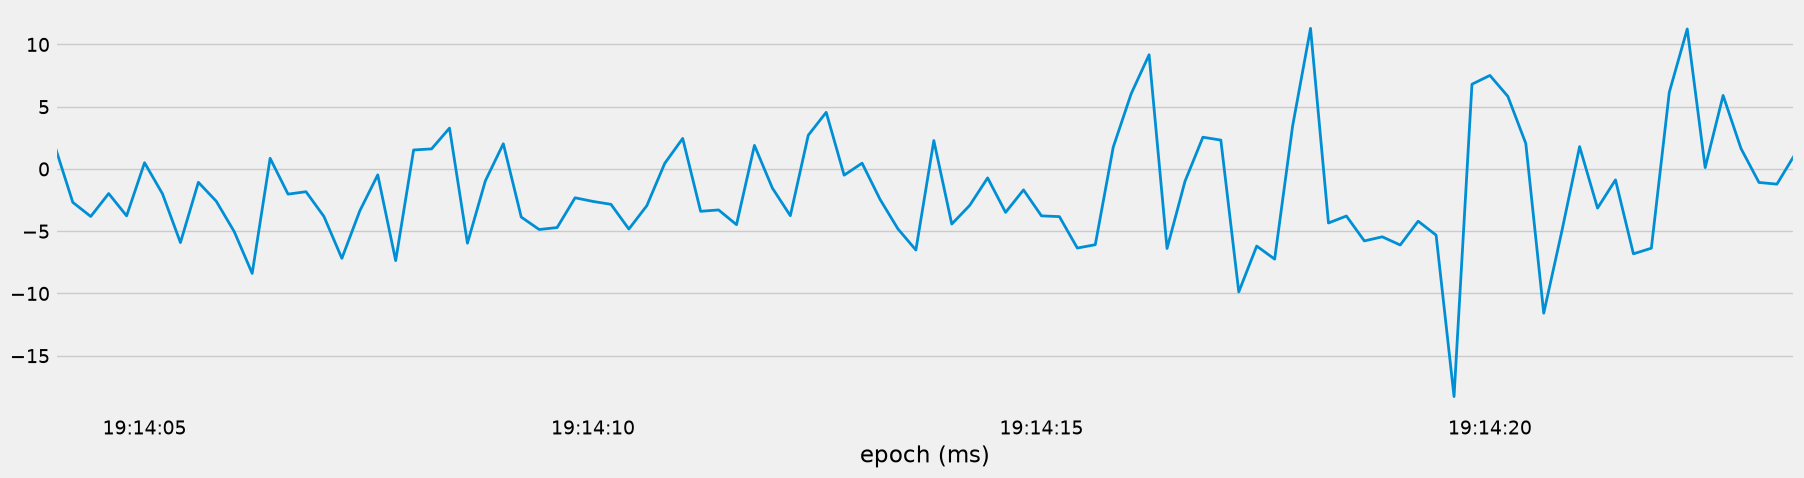

In [4]:
#cheking single row for refrence
subset = df[df["set"] == 30]["gyr_y"].plot()
subset

In [5]:
#using the interpolate data to predict and fill the missing value

for col in predictor_columns:
    df[col] = df[col].interpolate()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   acc_x         9009 non-null   float64
 1   acc_y         9009 non-null   float64
 2   acc_z         9009 non-null   float64
 3   gyr_x         9009 non-null   float64
 4   gyr_y         9009 non-null   float64
 5   gyr_z         9009 non-null   float64
 6   participants  9009 non-null   object 
 7   label         9009 non-null   object 
 8   Category      9009 non-null   object 
 9   set           9009 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 774.2+ KB


In [6]:
#Calculate the avg duration of set to get the lowpass of each set, we can get the time delta then calculate the time for each set

duration = df[df["set"] == 1].index[-1] - df[df["set"] == 1].index[0] 
duration.seconds

for s in df["set"].unique():
    start = df[df["set"] == s].index[-1] 
    stop =  df[df["set"] == s].index[0] 

    duration = start - stop
    df.loc[(df["set"]==s), "duration"] = duration.seconds

duration_df = df.groupby(["Category"])["duration"].mean()

print(duration_df.iloc[0] / 5)    #heavy set with 5 set
print(duration_df.iloc[1] / 10)

2.9487001733102254
2.4942528735632186


## Butterworth Low-pass filer

A butterworth low-pass filter is a type of filter that is used to remove the high frequency noise from a dataset. It is most commonly used in the machine learning in order to imporve the accuracy of the model. The filter works by removing any data points above a cetain threshold frequency, while still preserving the underlying pattern of the data. By doing so, it helps to reduce the effects of noise on the model, which can leads to better result

squat


/tmp/ipykernel_29393/1630305736.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(subset['label'][0])


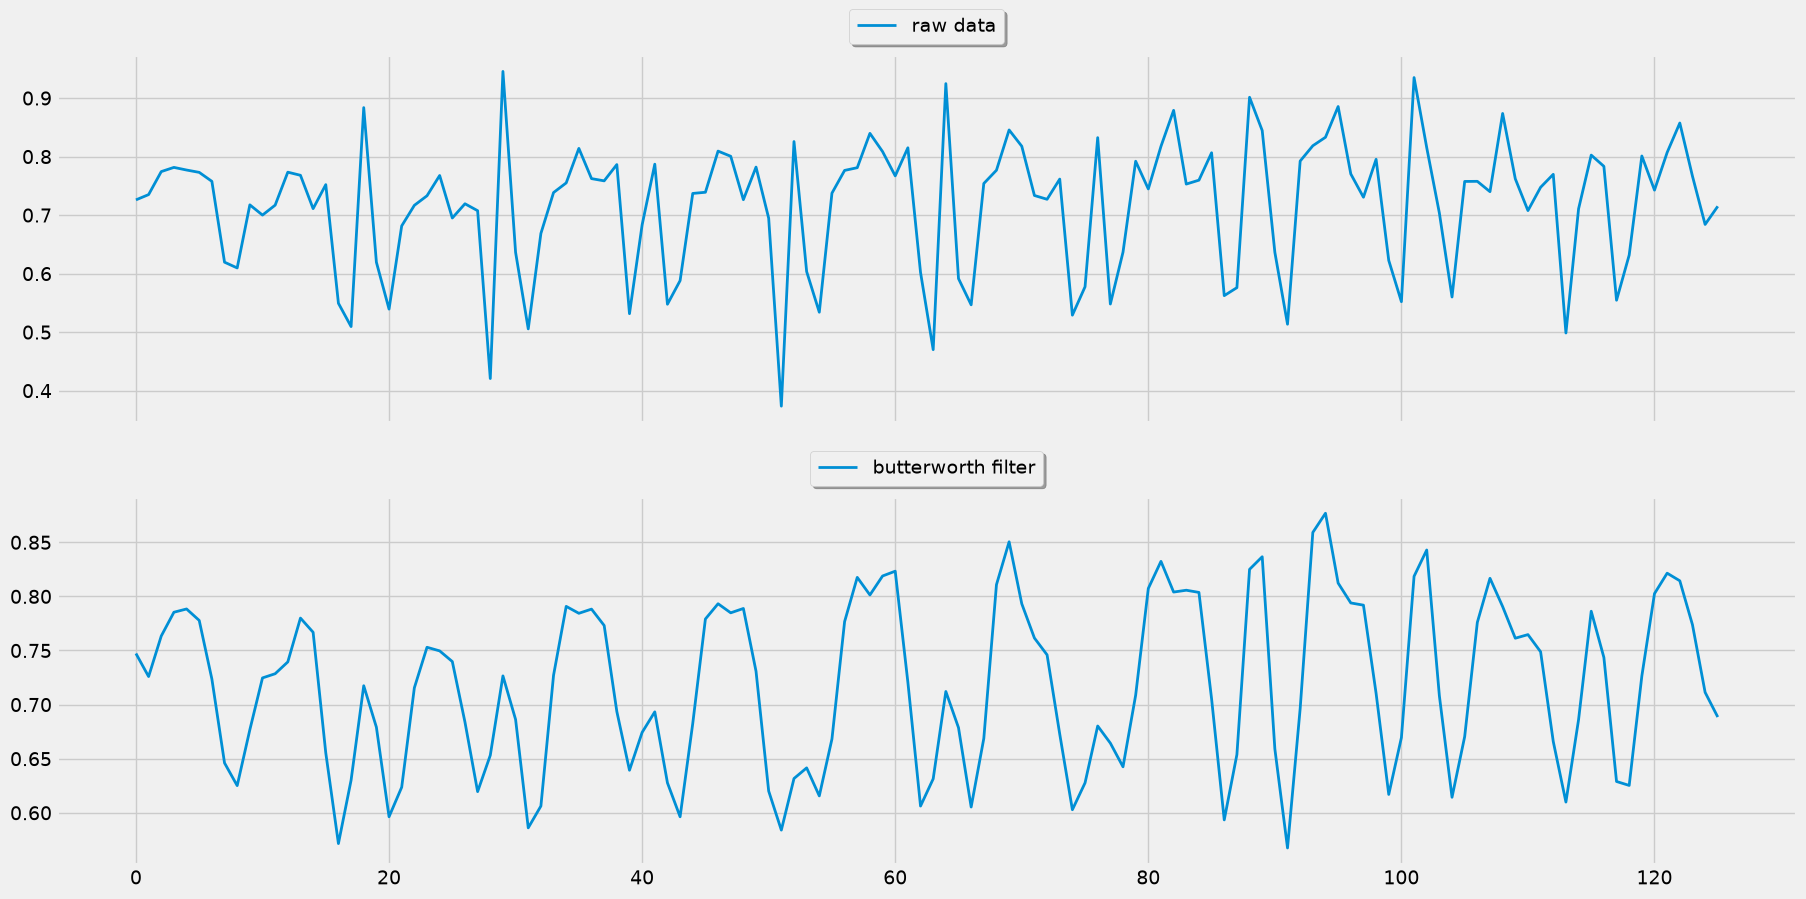

In [7]:
#--------------------------------------------------------
#Butterworth Low-pass filter
#--------------------------------------------------------

#we are trying to remove the noise from the frequency and create as smoothercurve in the grapgh

df_lowpass = df.copy()
Lowpass = LowPassFilter()

fs = 1000 / 200  # basically it means 5, 1000 movements in 200 microseconds
cutoff = 1.3     #fs and cutoff are agruments of the new funtion called in lowpass mentioned in documentry of lowpass function

df_lowpass = Lowpass.low_pass_filter(df_lowpass, "acc_y", fs, cutoff, order=5)  #all arguments mentioned in documentation

subset = df_lowpass[df_lowpass['set'] == 45]
print(subset['label'][0])


fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20,10))
ax[0].plot(subset["acc_y"].reset_index(drop=True), label ="raw data")
ax[1].plot(subset["acc_y_lowpass"].reset_index(drop=True), label ="butterworth filter")

ax[0].legend(loc="upper center", bbox_to_anchor =(0.5, 1.15), ncol=3, fancybox=True, shadow=True) #adding ledgend
ax[1].legend(loc="upper center", bbox_to_anchor =(0.5, 1.15), ncol=3, fancybox=True, shadow=True)


In [8]:
# Now applying the filter in all data by using filter
# we are removing the old data with lowpass frequency data, preparing for PCA

for col in predictor_columns:
    df_lowpass = Lowpass.low_pass_filter(df_lowpass, col, fs, cutoff, order=5)
    df_lowpass[col] = df_lowpass[col+"_lowpass"]
    del df_lowpass[col+"_lowpass"]    

In [9]:
# noise from the data has been smooth
df_lowpass

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,participants,label,Category,set,duration
epoch (ms),,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,69,16.0
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,69,16.0
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,69,16.0
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,69,16.0
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,69,16.0
...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,56,19.0
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,56,19.0
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,56,19.0


## Principle Component Analysis

PCA is a techique used in Machine Learning to reduce the complexity of the data by transforming the data into a new set of variables called pricipal components. This transformation is done is such a way that the new set of variables captures the most amount of information from the orginal data set, while reducing the the number of variables necessary. This helps to reduces the complexity of the data and make it easier to analyse and make predictions from.

----

#### Elbow Technique
The elbow technique is a method used to determine the optimal number of components to use when conducting a PCA. It works by testing multiple diffrent component numbers and then evaluating the variance captured by each component number. The optimal component number is often chosen as the number of component that capture the most variance while also not incorporating too many components. This is done by plotting the variance captured against the component number and then selecting the point at which the rate of change in variance diminishes (the elbow), as this is typically the point at which adding more components does not significally improves the analysis. 

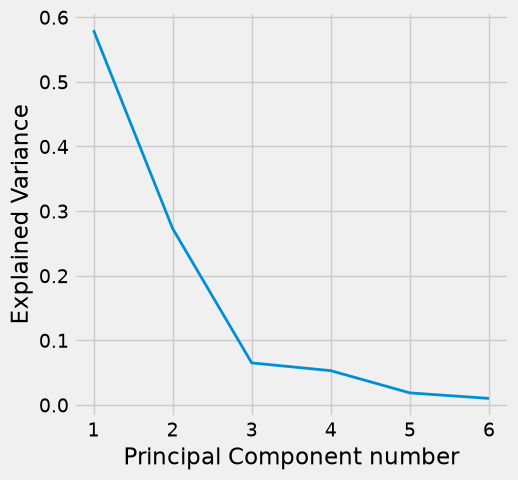

In [10]:
df_pca = df_lowpass.copy()
PCA = PrincipalComponentAnalysis()

pc_values = PCA.determine_pc_explained_variance(df_pca, predictor_columns)

plt.figure(figsize=(5,5))
plt.plot(range(1, len(predictor_columns)+1), pc_values)
plt.xlabel("Principal Component number")
plt.ylabel("Explained Variance")
plt.show()

In [11]:
#using the applly_pca function to apply the pca to df

df_pca = PCA.apply_pca(df_pca, predictor_columns, 3)
df_pca

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,participants,label,Category,set,duration,pca_1,pca_2,pca_3
epoch (ms),,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,69,16.0,0.315889,-0.075461,0.072243
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,69,16.0,0.314873,-0.073888,0.069825
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,69,16.0,0.314236,-0.080343,0.066219
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,69,16.0,0.314356,-0.090852,0.061839
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,69,16.0,0.313630,-0.097479,0.062974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,56,19.0,-0.349351,-0.148450,-0.053031
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,56,19.0,-0.371610,-0.151455,-0.058498
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,56,19.0,-0.368098,-0.153153,-0.058772


<Axes: xlabel='epoch (ms)'>

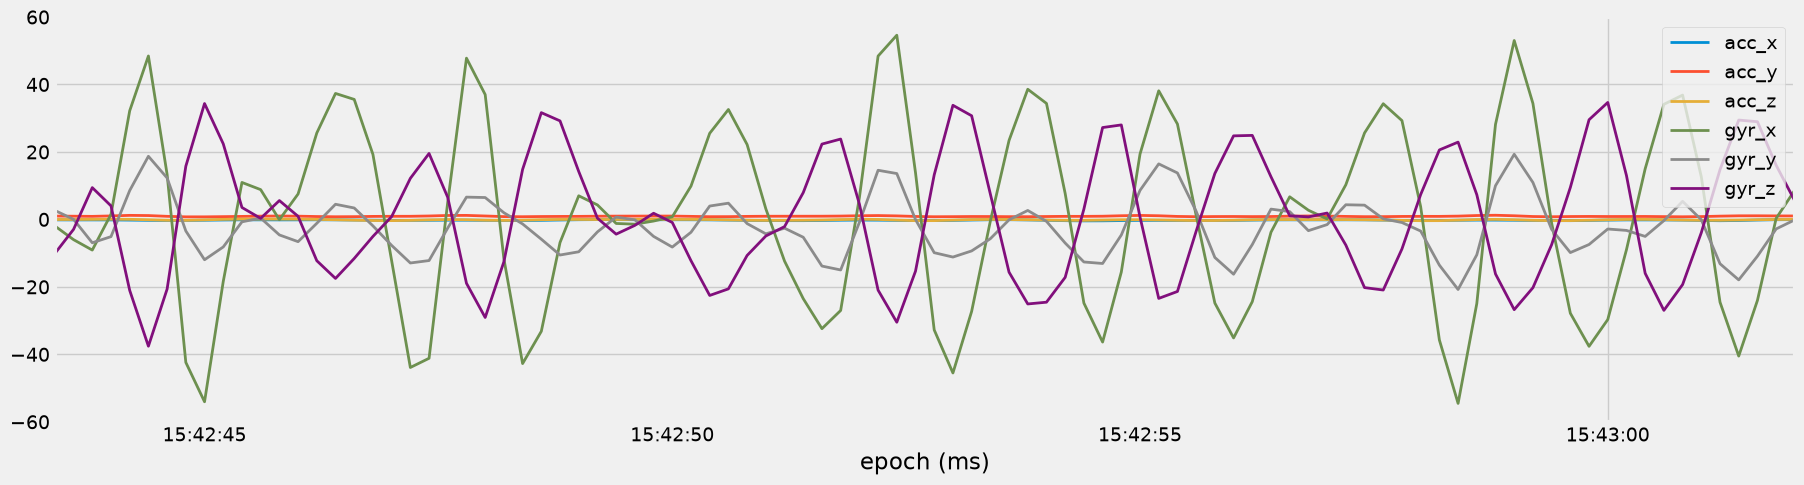

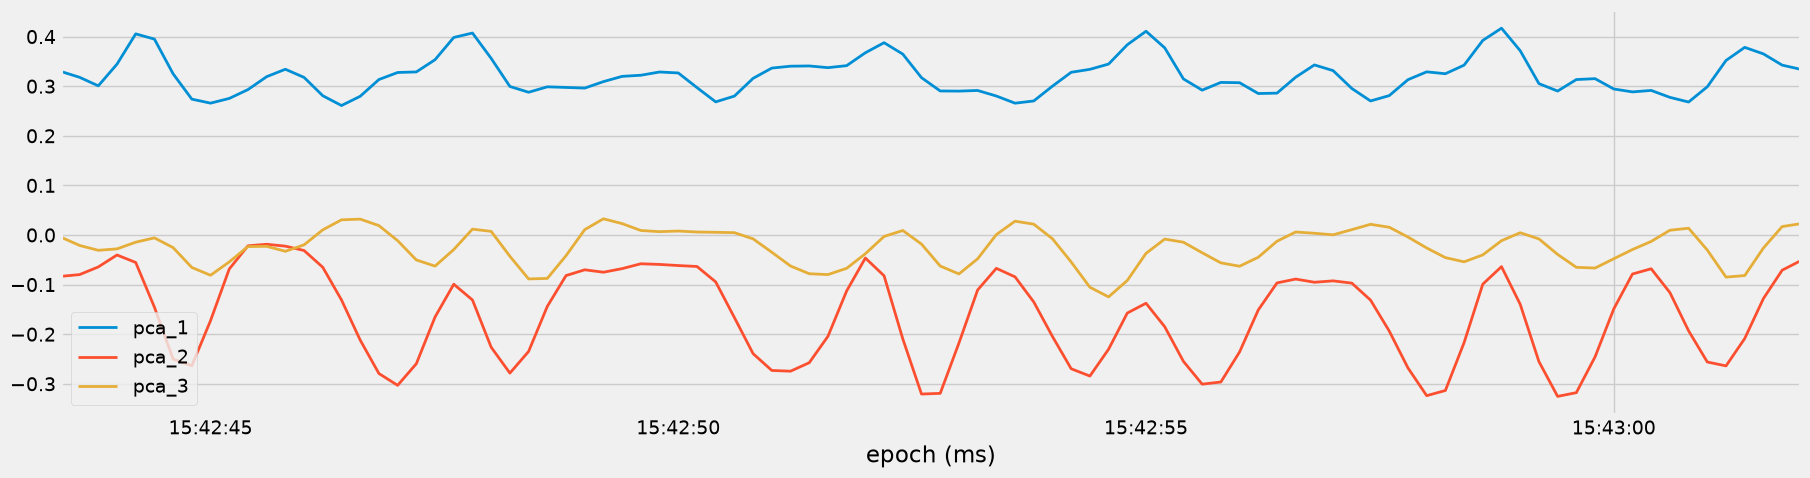

In [12]:
# the data and the PCA data comparsion
df_pca[df_pca['set']==35][["acc_x","acc_y","acc_z","gyr_x","gyr_y","gyr_z"]].plot()

df_pca[df_pca['set']==35][["pca_1","pca_2","pca_3"]].plot()

# Sum of Squares

Adding new Features, to explore in future. to further exploit the data the scalar Magnitude **r** of the accelerometer and Gyroscope, were calculated. The advantage of using r is that it is imparital to the device orientation and can handle dynamic re-orientation.

r = np.sqrt(x^2 + y^2 + z^2)

array([<Axes: xlabel='epoch (ms)'>, <Axes: xlabel='epoch (ms)'>],
      dtype=object)

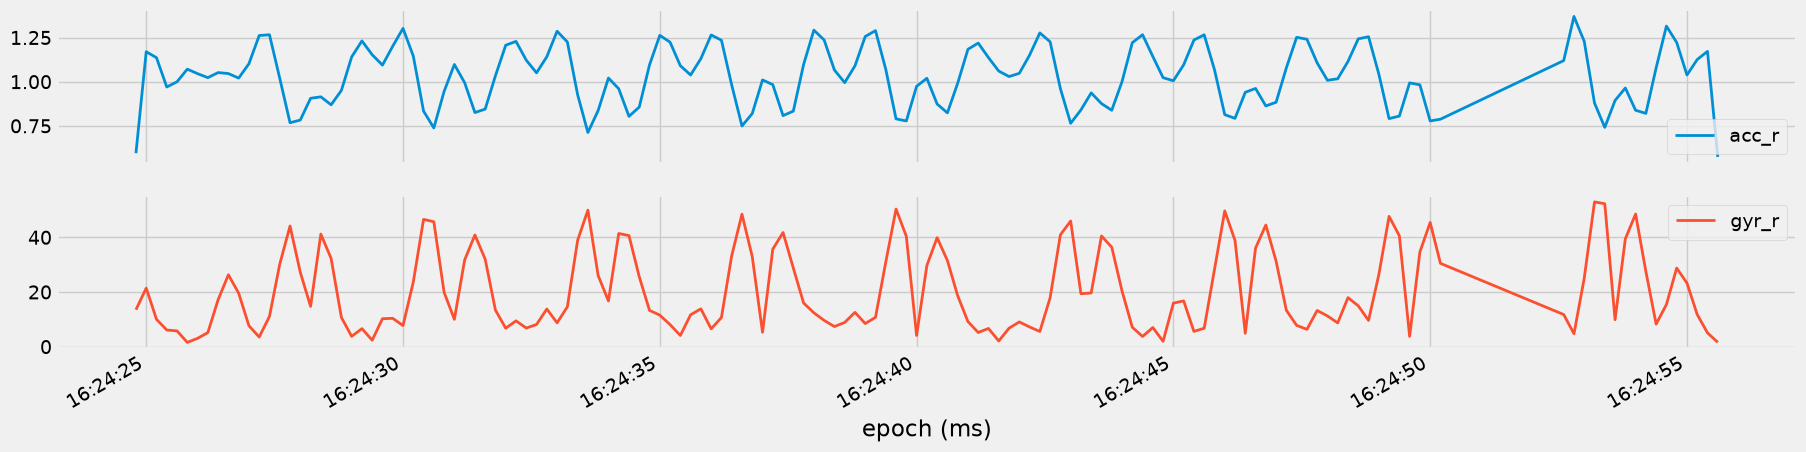

In [13]:
df_squared = df_pca.copy()

acc_r = df_squared["acc_x"]**2 + df_squared["acc_y"]**2 + df_squared["acc_z"]**2
gyr_r = df_squared["gyr_x"]**2 + df_squared["gyr_y"]**2 + df_squared["gyr_z"]**2

df_squared['acc_r'] = np.sqrt(acc_r)
df_squared['gyr_r'] = np.sqrt(gyr_r)

subset = df_squared[df_squared["set"]== 14]
subset[["acc_r","gyr_r"]].plot(subplots=True)

# Temporal Abstraction

We are trying to create rolling avg of all the colomns, the all 6 data colomns and adding 2 new squared colomns as well

In [14]:
# Temporal Abstraction
#abstract_numerical(self, data_table, cols, window_size, aggregation_function)

df_temporal = df_squared.copy()
numAbs = NumericalAbstraction()

predictor_columns = predictor_columns + ["acc_r", "gyr_r"]

ws = int(1000/200)           #getting the window size

'''
Testing for col, this will not be used because of our data, It has combined data of multiple set together. One set complete then move to
next set, but moving avg will caluclate the preciditing value and first 5 data points will errors and this error will be added to over all
data.

So, we have to create window of each set, take the avg and update the moving avg as per set not per entire data.

for col in predictor_columns:
    df_temporal = numAbs.abstract_numerical(df_temporal, [col], ws, "mean")
    df_temporal = numAbs.abstract_numerical(df_temporal, [col], ws, "std")
'''


df_temporal_list = []

for s in df_temporal["set"].unique():
    subset = df_temporal[df_temporal["set"]==s].copy()         #creating a small copy form temporal to subset for each set for procaution
    for col in predictor_columns:
        subset = numAbs.abstract_numerical(subset, [col], ws, "mean")
        subset = numAbs.abstract_numerical(subset, [col], ws, "std")
    df_temporal_list.append(subset)

df_temporal_list = pd.concat(df_temporal_list)


In [15]:
display(df_temporal_list.head())
df_temporal_list.info()

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,participants,label,Category,set,...,gyr_x_temp_mean_ws_5,gyr_x_temp_std_ws_5,gyr_y_temp_mean_ws_5,gyr_y_temp_std_ws_5,gyr_z_temp_mean_ws_5,gyr_z_temp_std_ws_5,acc_r_temp_mean_ws_5,acc_r_temp_std_ws_5,gyr_r_temp_mean_ws_5,gyr_r_temp_std_ws_5
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,69,...,1.522572,2.602489,-0.771259,2.043684,-0.512552,0.971453,0.971141,0.005643,3.39369,1.884665


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   acc_x                 9009 non-null   float64
 1   acc_y                 9009 non-null   float64
 2   acc_z                 9009 non-null   float64
 3   gyr_x                 9009 non-null   float64
 4   gyr_y                 9009 non-null   float64
 5   gyr_z                 9009 non-null   float64
 6   participants          9009 non-null   object 
 7   label                 9009 non-null   object 
 8   Category              9009 non-null   object 
 9   set                   9009 non-null   int64  
 10  duration              9009 non-null   float64
 11  pca_1                 9009 non-null   float64
 12  pca_2                 9009 non-null   float64
 13  pca_3                 9009 non-null   float64
 14  acc_r                 

<Axes: xlabel='epoch (ms)'>

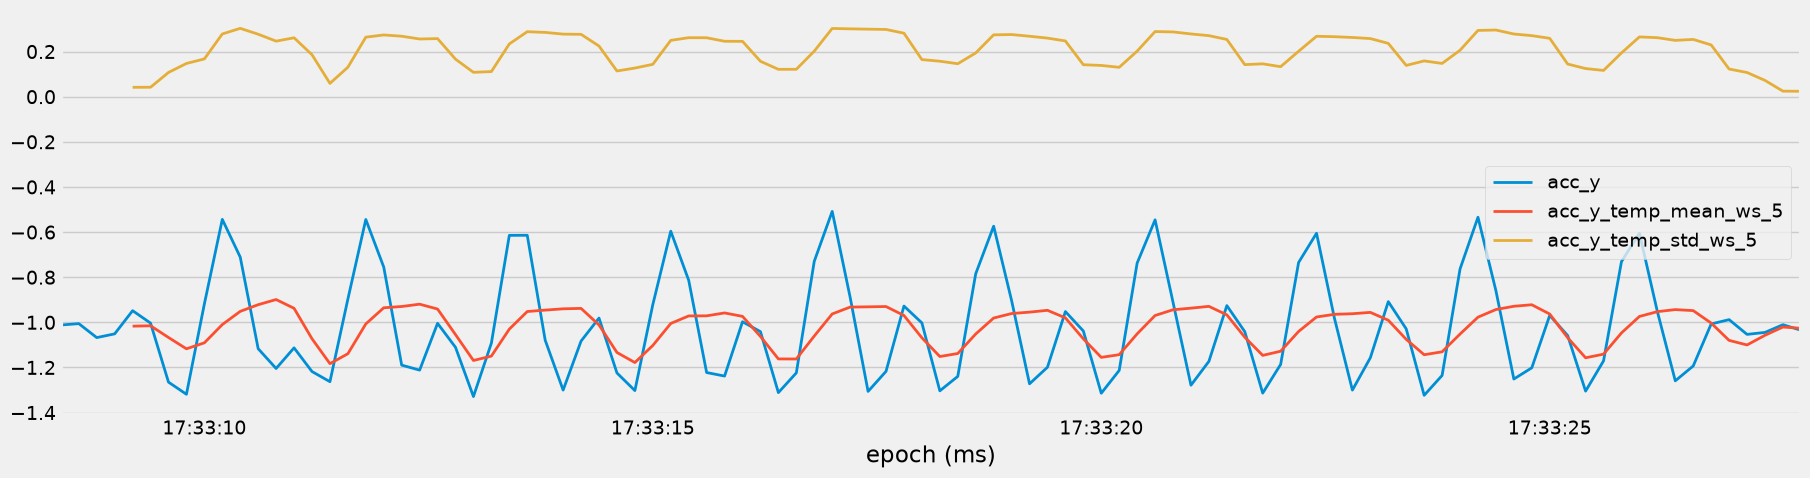

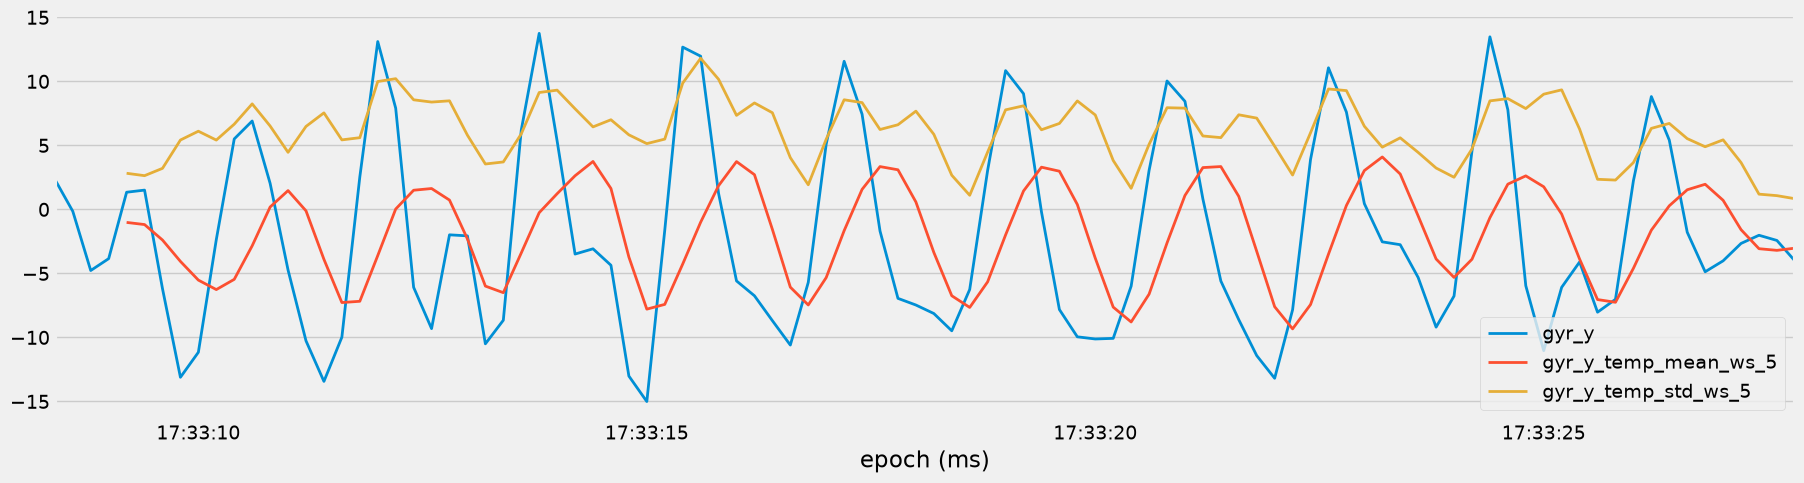

In [16]:
subset[["acc_y", "acc_y_temp_mean_ws_5", "acc_y_temp_std_ws_5"]].plot()
subset[["gyr_y", "gyr_y_temp_mean_ws_5", "gyr_y_temp_std_ws_5"]].plot()

# Discrete Fourier Transformation (DFT)

The idea of a Fourier transformation is that any sequence of measurements we perform can be represented by a combination of sinusoid functionswith different frequencie.

A DFT is beneficial for machine learning, as it can be used to represent data in terms of frequency components, allowing for more efficient analysis of the data. This provides a way to better understand and model complex data sets, as the frequency components produced by the DFT can provide insight into pattern and trends that would not otherwise be visible.

Additionally we will be extracting:
 
- Amplitude (for each of the relevent frequencies that are part of the window)
- Max frequency
- Weighted Frequency (average)
- Power sprctral entorpy 

In [27]:
# Frequency features

from FrequencyAbstraction import FourierTransformation

df_freq = df_temporal_list.copy().reset_index()
FreqAbs = FourierTransformation()

fs = int(1000 / 200)    #fs 5
ws = int(2800 / 200)    #avg frequecy of repeating exercise in 14 sec

#for one colomn.
#df_freq = FreqAbs.abstract_frequency(df_freq, ["acc_y"], ws, fs)

# We have to do the trasnformation on all the colomns

df_freq_list = []

for s in df_freq["set"].unique():
    
    print(f"Applying Fouier Trasnsformation for set {s}")
    
    subset = df_freq[df_freq["set"]==s].reset_index(drop=True).copy()
    subset = FreqAbs.abstract_frequency(subset, predictor_columns, ws, fs)
    df_freq_list.append(subset)

Applying Fouier Trasnsformation for set 69
Applying Fouier Trasnsformation for set 59
Applying Fouier Trasnsformation for set 61
Applying Fouier Trasnsformation for set 21
Applying Fouier Trasnsformation for set 6
Applying Fouier Trasnsformation for set 87
Applying Fouier Trasnsformation for set 9
Applying Fouier Trasnsformation for set 35
Applying Fouier Trasnsformation for set 90
Applying Fouier Trasnsformation for set 5
Applying Fouier Trasnsformation for set 26
Applying Fouier Trasnsformation for set 23
Applying Fouier Trasnsformation for set 44
Applying Fouier Trasnsformation for set 7
Applying Fouier Trasnsformation for set 29
Applying Fouier Trasnsformation for set 63
Applying Fouier Trasnsformation for set 43
Applying Fouier Trasnsformation for set 83
Applying Fouier Trasnsformation for set 45
Applying Fouier Trasnsformation for set 68
Applying Fouier Trasnsformation for set 14
Applying Fouier Trasnsformation for set 12
Applying Fouier Trasnsformation for set 76
Applying Fouier

In [28]:
#combing the list into a proper df_freq

df_freq = pd.concat(df_freq_list)

In [35]:
df_freq = df_freq.set_index("epoch (ms)", drop=True)
df_freq

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,participants,label,Category,set,...,gyr_r_freq_weighted,gyr_r_pse,gyr_r_freq_0.0_Hz_ws_14,gyr_r_freq_0.357_Hz_ws_14,gyr_r_freq_0.714_Hz_ws_14,gyr_r_freq_1.071_Hz_ws_14,gyr_r_freq_1.429_Hz_ws_14,gyr_r_freq_1.786_Hz_ws_14,gyr_r_freq_2.143_Hz_ws_14,gyr_r_freq_2.5_Hz_ws_14
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:05.200,0.013503,0.977003,-0.071001,-1.886218,2.438803,0.937522,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.400,0.008515,0.973169,-0.066481,-0.367396,0.439794,0.178360,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.600,-0.008450,0.966879,-0.071895,4.320608,-2.083978,-1.217263,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:05.800,-0.024359,0.962244,-0.084774,4.737252,-3.456339,-0.678205,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-11 15:08:06.000,-0.022092,0.959572,-0.096776,0.808615,-1.194575,-1.783172,B,bench,heavy,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,56,...,-0.255402,0.238607,319.521621,-34.907878,31.861740,9.784884,1.149502,-51.406834,-1.543486,0.948401
2019-01-20 17:33:27.200,-0.041403,-1.053448,-0.064530,-2.967835,-2.660315,1.584934,E,row,medium,56,...,0.536997,0.660463,308.391215,-44.886326,66.358365,78.568468,-20.114545,64.769560,14.905502,8.625034
2019-01-20 17:33:27.400,-0.048048,-1.044737,-0.065951,-0.043109,-2.022091,1.155930,E,row,medium,56,...,0.633179,0.577277,267.731227,-73.117861,40.866650,37.338879,18.436116,18.097675,21.450904,33.080361


### Deling with overlaping data and remove the highly correlated data

### We can use Kmean to create clustering

#### KMeans Clustering

K-means clustering is an unsupervised machine learning algorithm used to group data into clutser based on similarity. It randomly initilize k points (centroid) in the data space, calculates the distance between is a popular feature engineering techniques used in many applications such as identifying the most important features in a dataset, segmenting customers into diffrent clusters based on thire purchac behaviour anomaly detection and image compression

In [39]:

# drop the missing value
df_freq = df_freq.dropna()

# drop the alternate row as it time series and less variation is there so it will help in reducing overfitting. 50% overlap data removed
df_freq = df_freq.iloc[::2]

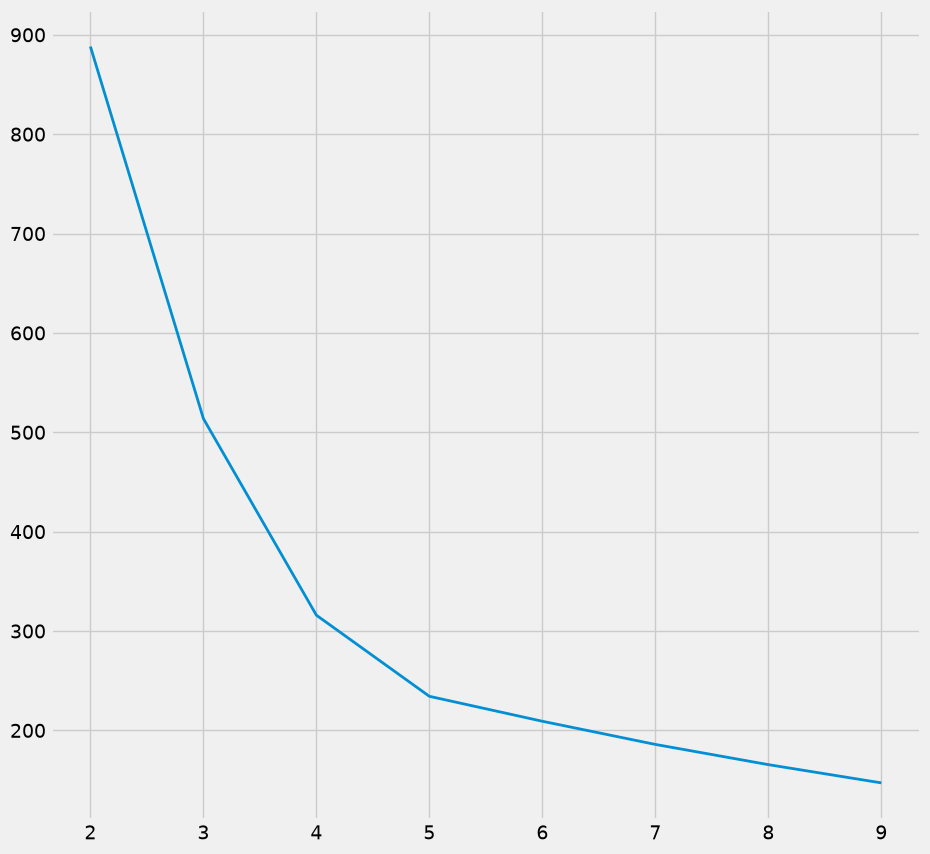

In [41]:
#Creating clustering using Kmean, to group data based on similar data

df_cluster = df_freq.copy()

cluster_colomns = ["acc_x","acc_y","acc_z"]
k_values = range(2,10)
intertias = []

for k in k_values:
    subset = df_cluster[cluster_colomns]
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
    cluster_label = kmeans.fit_predict(subset)
    intertias.append(kmeans.inertia_)


# plot grapgh to determine the intertia value

plt.figure(figsize=(10,10))
plt.plot(k_values,intertias)
plt.show()

In [42]:
kmeans = KMeans(n_clusters=5, n_init=20, random_state=0)
subset = df_cluster[cluster_colomns]
df_cluster["cluster"] = kmeans.fit_predict(subset)

df_cluster

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,participants,label,Category,set,...,gyr_r_pse,gyr_r_freq_0.0_Hz_ws_14,gyr_r_freq_0.357_Hz_ws_14,gyr_r_freq_0.714_Hz_ws_14,gyr_r_freq_1.071_Hz_ws_14,gyr_r_freq_1.429_Hz_ws_14,gyr_r_freq_1.786_Hz_ws_14,gyr_r_freq_2.143_Hz_ws_14,gyr_r_freq_2.5_Hz_ws_14,cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:08.000,-0.172350,0.909033,-0.168556,-27.895242,-10.831760,26.285743,B,bench,heavy,69,...,0.404506,241.915837,-32.414519,17.800054,-7.090627,-23.559585,15.300362,-56.937517,-9.887314,1
2019-01-11 15:08:08.400,-0.024777,0.860474,-0.059254,-2.040040,-1.316930,1.986210,B,bench,heavy,69,...,0.376805,266.641927,-45.027971,-65.743054,-12.016695,8.716330,14.278175,5.797033,-2.207473,1
2019-01-11 15:08:08.800,-0.063378,0.997048,-0.033869,1.164754,-1.844231,-1.240332,B,bench,heavy,69,...,0.508919,262.078311,-56.234625,-30.091473,3.458370,-13.917311,-48.217504,42.767778,-11.602442,1
2019-01-11 15:08:09.200,-0.044993,0.971809,-0.038011,2.469483,-3.482648,3.563210,B,bench,heavy,69,...,0.492961,256.245567,-31.989318,69.348370,3.624009,17.424045,36.328368,26.990522,-9.999852,1
2019-01-11 15:08:09.600,-0.046925,0.911220,-0.056463,8.471911,4.745072,-8.708681,B,bench,heavy,69,...,0.363189,214.663711,-12.227055,13.687545,10.833066,6.326124,25.453064,-35.551747,-33.538487,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:26.200,0.063910,-0.952114,0.107673,-38.792016,8.810964,14.997831,E,row,medium,56,...,0.350704,368.429928,29.216316,-57.045603,10.239165,-47.609218,-37.827325,-17.620149,-36.551825,3
2019-01-20 17:33:26.600,-0.024266,-1.193314,-0.109309,-2.783290,-1.783932,6.232364,E,row,medium,56,...,0.324461,379.719977,39.879652,-21.517667,-13.542762,27.460451,82.477003,22.715838,9.757813,0
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,56,...,0.238607,319.521621,-34.907878,31.861740,9.784884,1.149502,-51.406834,-1.543486,0.948401,0


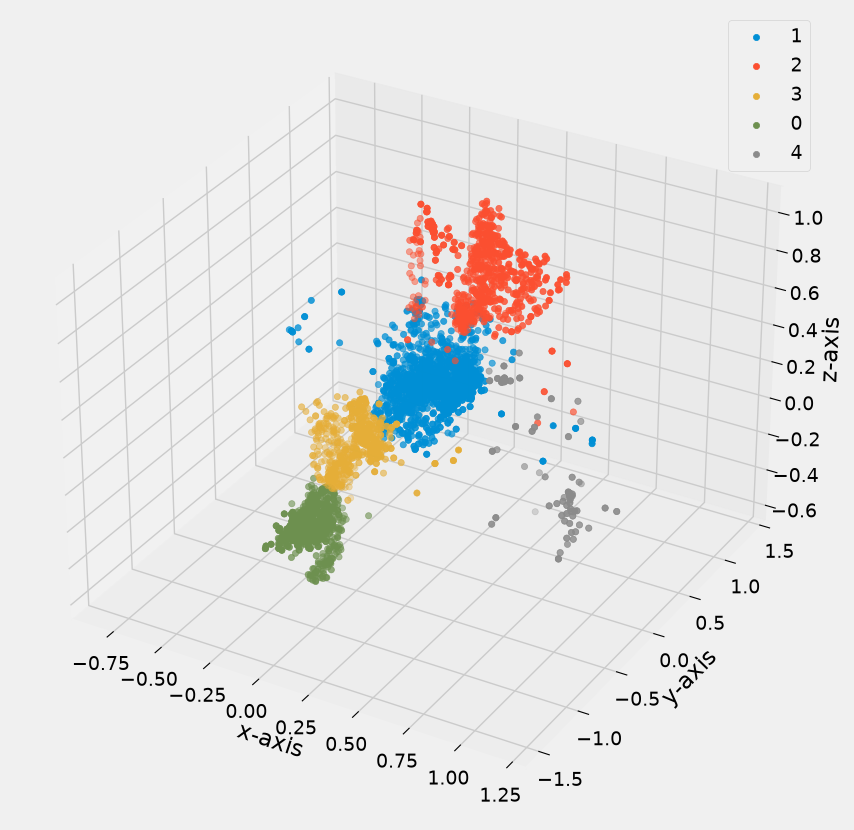

In [47]:
#Plotting the cluster

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")

for c in df_cluster["cluster"].unique():
    subset = df_cluster[df_cluster["cluster"] == c]
    ax.scatter(subset["acc_x"], subset["acc_y"], subset["acc_z"], label =c)

ax.set_xlabel ("x-axis")
ax.set_ylabel ("y-axis")
ax.set_zlabel ("z-axis")
plt.legend()
plt.show()

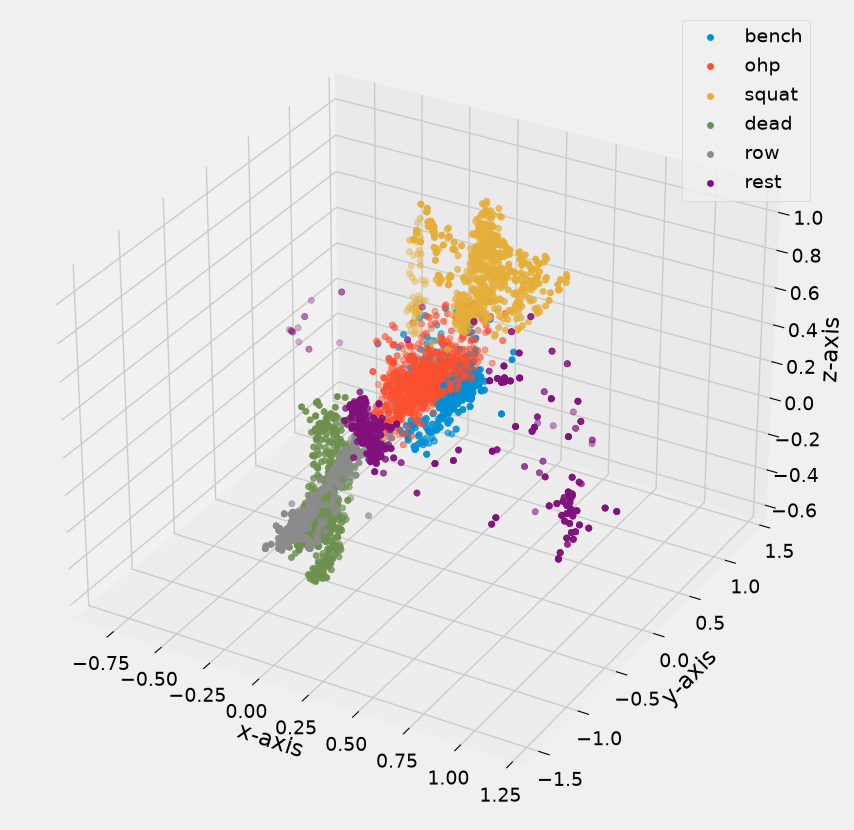

In [49]:
# plot by unique lable
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")

for c in df_cluster["label"].unique():
    subset = df_cluster[df_cluster["label"] == c]
    ax.scatter(subset["acc_x"], subset["acc_y"], subset["acc_z"], label =c)

ax.set_xlabel ("x-axis")
ax.set_ylabel ("y-axis")
ax.set_zlabel ("z-axis")
plt.legend()
plt.show()

In [50]:
## Exporting the data

df_cluster.to_pickle("../../data/interim/03_feature_eng.pkl")